In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
    #Data

students = {
    'Name':['Akshat', 'Raj', 'Sunil', 'Vijay','Rohit', 'Ojas', 'Kirti', 'Shreya'],
    'Maths': [85, 72, 90, 65, 78, 88, 55, 92],
    'Science': [78, 68, 85, 70, 82, 75, 60, 88],
    'English': [82, 75, 88, 72, 70, 80, 65, 85],
    'History': [70, 80, 75, 68, 65, 72, 58, 78],
    'Computer':[90, 65, 92, 80, 85, 95, 70, 96]
}

df = pd.DataFrame(students)
df

,Name,Maths,Science,English,History,Computer
0,Akshat,85,78,82,70,90
1,Raj,72,68,75,80,65
2,Sunil,90,85,88,75,92
3,Vijay,65,70,72,68,80
4,Rohit,78,82,70,65,85
5,Ojas,88,75,80,72,95
6,Kirti,55,60,65,58,70
7,Shreya,92,88,85,78,96


In [8]:
    #Analysis

subjects = ['Maths','Science','English','History','Computer']

df['Total'] = df[subjects].sum(axis=1)
df['Average'] = df[subjects].mean(axis=1).round(2)
df['Percentage'] = ((df['Total']/500)*100).round(2)

def grades(avg):
  if avg >= 90:
        return 'A'
  elif avg >= 80:
        return 'B'
  elif avg >= 70:
        return 'C'
  elif avg >= 60:
        return 'D'
  else:
        return 'F'

df['Grade'] = df['Average'].apply(grades)
df['Status'] = df['Average'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

df


,Name,Maths,Science,English,History,Computer,Total,Average,Percentage,Grade,Status
0,Akshat,85,78,82,70,90,405,81.0,81.0,B,Pass
1,Raj,72,68,75,80,65,360,72.0,72.0,C,Pass
2,Sunil,90,85,88,75,92,430,86.0,86.0,B,Pass
3,Vijay,65,70,72,68,80,355,71.0,71.0,C,Pass
4,Rohit,78,82,70,65,85,380,76.0,76.0,C,Pass
5,Ojas,88,75,80,72,95,410,82.0,82.0,B,Pass
6,Kirti,55,60,65,58,70,308,61.6,61.6,D,Pass
7,Shreya,92,88,85,78,96,439,87.8,87.8,B,Pass


In [9]:
    #Report

print("="*55)
print("      STUDENT PERFORMANCE REPORT")
print("="*55)
print(df[['Name','Total','Average','Percentage','Grade','Status']].to_string(index = False))
print("="*55)
print(f"Class Topper: {df.loc[df['Average'].idxmax(), 'Name']}")
print(f"Highest Score: {df['Average'].max()}")
print(f"Class Average: {df['Average'].mean().round(2)}")
print(f"Students Failed: {(df['Status'] == 'Fail').sum()}")
print("="*55)

      STUDENT PERFORMANCE REPORT
  Name  Total  Average  Percentage Grade Status
Akshat    405     81.0        81.0     B   Pass
   Raj    360     72.0        72.0     C   Pass
 Sunil    430     86.0        86.0     B   Pass
 Vijay    355     71.0        71.0     C   Pass
 Rohit    380     76.0        76.0     C   Pass
  Ojas    410     82.0        82.0     B   Pass
 Kirti    308     61.6        61.6     D   Pass
Shreya    439     87.8        87.8     B   Pass
Class Topper: Shreya
Highest Score: 87.8
Class Average: 77.18
Students Failed: 0


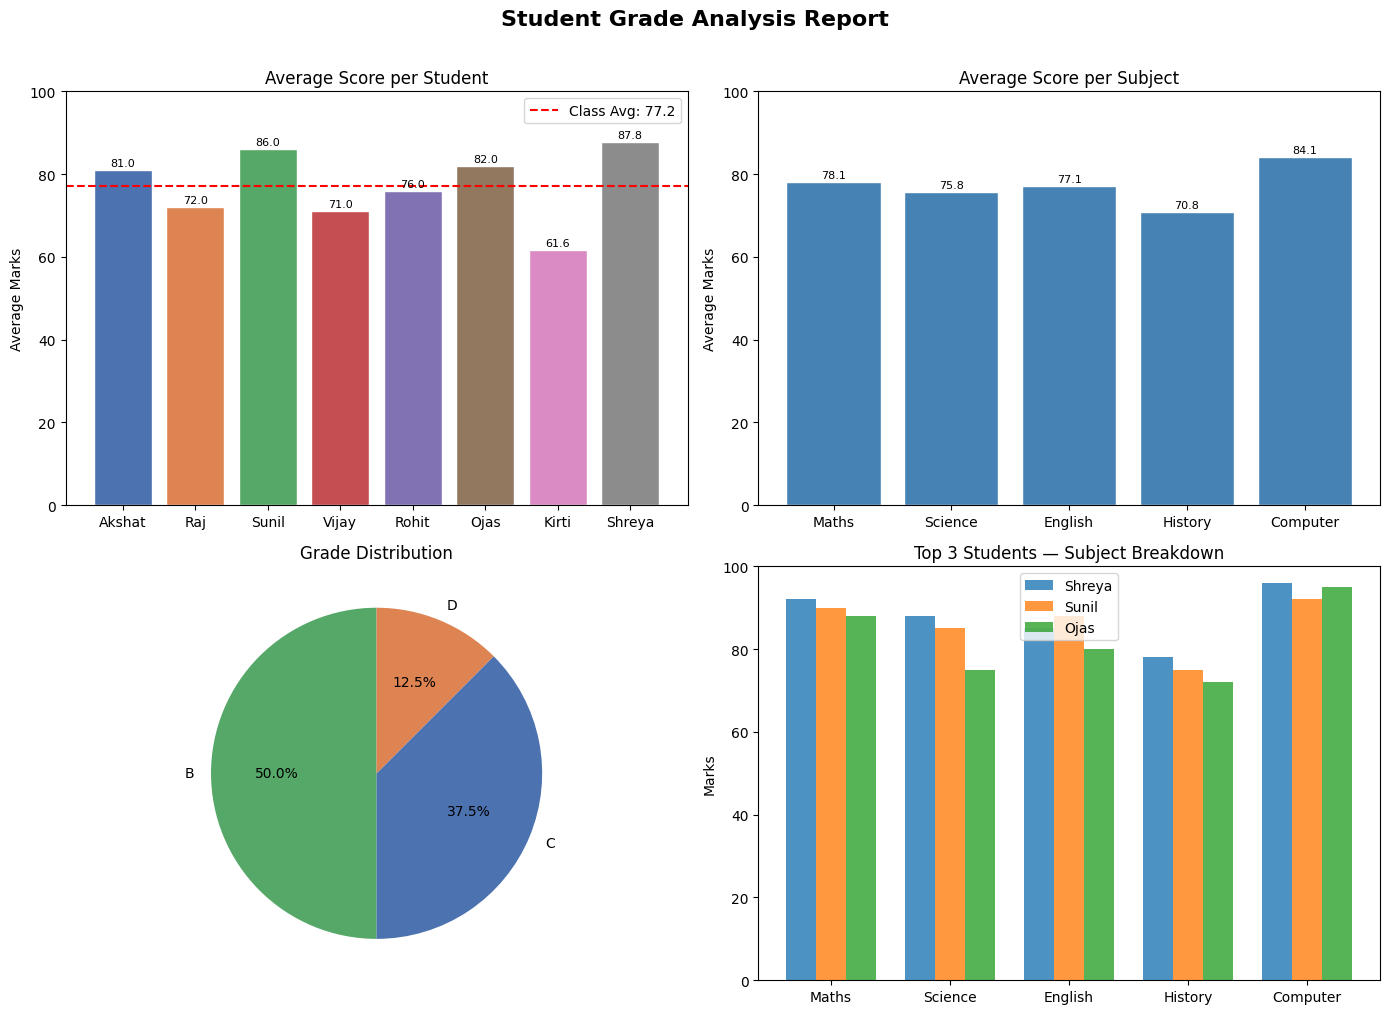


Report saved as grade_report.png


In [17]:
    #visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Grade Analysis Report',
             fontsize=16, fontweight='bold', y=1.01)

colors = ['#4C72B0','#DD8452','#55A868',
          '#C44E52','#8172B3','#937860',
          '#DA8BC3','#8C8C8C']

axes[0,0].bar(df['Name'], df['Average'],
              color=colors, edgecolor='white')
axes[0,0].axhline(y=df['Average'].mean(),
                   color='red', linestyle='--',
                   label=f"Class Avg: {df['Average'].mean():.1f}")
axes[0,0].set_title('Average Score per Student')
axes[0,0].set_ylabel('Average Marks')
axes[0,0].legend()
axes[0,0].set_ylim(0, 100)
for i, (name, avg) in enumerate(
        zip(df['Name'], df['Average'])):
          axes[0,0].text(i, avg + 1, str(avg),
                   ha='center', fontsize=8)


subject_avgs = df[subjects].mean()
axes[0,1].bar(subjects, subject_avgs,
              color='steelblue', edgecolor='white')
axes[0,1].set_title('Average Score per Subject')
axes[0,1].set_ylabel('Average Marks')
axes[0,1].set_ylim(0, 100)
for i, avg in enumerate(subject_avgs):
      axes[0,1].text(i, avg + 1, f'{avg:.1f}',
                   ha='center', fontsize=8)

grade_counts = df['Grade'].value_counts()
axes[1,0].pie(grade_counts.values,
              labels=grade_counts.index,
              autopct='%1.1f%%',
              colors=['#55A868','#4C72B0','#DD8452',
                      '#C44E52','#8172B3'],
              startangle=90)
axes[1,0].set_title('Grade Distribution')

top3 = df.nlargest(3, 'Average')['Name'].tolist()
x = np.arange(len(subjects))
width = 0.25

for i, name in enumerate(top3):
      scores = df[df['Name']==name][subjects].values[0]
      axes[1,1].bar(x + i*width, scores,
                  width, label=name, alpha=0.8)

axes[1,1].set_title('Top 3 Students — Subject Breakdown')
axes[1,1].set_xticks(x + width)
axes[1,1].set_xticklabels(subjects)
axes[1,1].set_ylabel('Marks')
axes[1,1].legend()
axes[1,1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('grade_report.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\nReport saved as grade_report.png")


In [18]:
!git config --global user.email "akshat.25bai10309@vitbhopal.ac.in"
!git config --global user.name "akshat25bai10309-svg"

In [19]:
import os
os.chdir('/content')
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
